# Reconstructing *The Tethered Viewer* with a Convolutional Autoencoder

**COGSCI 139 — Art, Geometry, and Cognition · Second Delivery**

## TL;DR

This notebook uses a small trained convolutional autoencoder to encode and reconstruct my selected work, *The Tethered Viewer*. The reconstruction preserves the broad room frame, central rectangle, foreground grouping, and some line directions, but it blurs handwriting and weakens or diffuses the red tether. The measured reconstruction error is reported below; it describes pixel loss in this model, not artistic quality or meaning.

## Context and method

The model was trained on 800 simple geometric images generated from perspective lines, nested frames, grids, arcs, radial connections, and occasional red connectors. It never trained on my artwork. The purpose is therefore not to imitate a style, but to ask which visual structures survive an encoder–decoder bottleneck.

### Key assumptions

- Input resolution is fixed at `128 × 128`.
- The checkpoint contains the weights learned during 18 training epochs.
- Mean squared error compares pixels; it cannot measure memory, authorship, or artistic value.

## Setup

The notebook uses the same compact model and trained checkpoint as the project experiment. It does not require `torchvision`; only PyTorch, Pillow, NumPy, and Matplotlib are used.

In [1]:
%matplotlib inline

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageOps
from torch import nn

SEED = 139
IMAGE_SIZE = 128
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Python/PyTorch environment ready: torch {torch.__version__}")
print(f"Fixed random seed: {SEED}")

Python/PyTorch environment ready: torch 2.11.0
Fixed random seed: 139


### Load the two submission assets

The notebook reads a small 128 × 128 copy of my artwork and the trained checkpoint from the neighboring `assets/` folder. Keeping binary data outside the notebook makes the Python code readable.

In [2]:
def findAsset(fileName: str) -> Path:
    searchRoots = [
        Path.cwd(),
        Path.cwd() / "submission",
        Path.cwd() / "OH_Programming" / "submission",
    ]
    for searchRoot in searchRoots:
        candidatePath = searchRoot / "assets" / fileName
        if candidatePath.is_file():
            return candidatePath.resolve()
    raise FileNotFoundError(
        f"Could not locate assets/{fileName}. Keep the assets folder beside the notebooks."
    )


artworkPath = findAsset("my-own-work-128.png")
checkpointPath = findAsset("geometric-autoencoder.pt")
print(f"Artwork:   {artworkPath.name}")
print(f"Checkpoint: {checkpointPath.name}")

Artwork:   my-own-work-128.png
Checkpoint: geometric-autoencoder.pt


### Model definition

The encoder lowers spatial resolution three times: `128 → 64 → 32 → 16`. The decoder then returns to `128 × 128`. There is no classifier, semantic label, attention mechanism, or skip connection.

In [3]:
class GeometricAutoencoder(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 12, kernel_size=5, stride=2, padding=2),
            nn.ReLU(inplace=False),
            nn.Conv2d(12, 24, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.Conv2d(24, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=False),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 24, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(24, 12, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(12, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, inputTensor: torch.Tensor) -> torch.Tensor:
        encodedTensor = self.encoder(inputTensor)
        return self.decoder(encodedTensor)


try:
    checkpoint = torch.load(checkpointPath, map_location="cpu", weights_only=False)
except TypeError:
    checkpoint = torch.load(checkpointPath, map_location="cpu")

model = GeometricAutoencoder()
model.load_state_dict(checkpoint["modelState"])
model.eval()

parameterCount = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {parameterCount:,}")
print(f"Training configuration: {checkpoint['config']}")

GeometricAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(3, 12, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): ReLU()
    (2): Conv2d(12, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(24, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 24, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(24, 12, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(12, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Sigmoid()
  )
)
Trainable parameters: 27,983
Training configuration: {'imageSize': 128, 'trainSamples': 800, 'epochs': 18, 'batchSize': 32, 'learningRate': 0.001, 'seed': 139}


In [4]:
with Image.open(artworkPath) as sourceImage:
    artworkImage = ImageOps.exif_transpose(sourceImage).convert("RGB")

artworkArray = np.asarray(artworkImage, dtype=np.float32) / 255.0
inputTensor = torch.from_numpy(artworkArray).permute(2, 0, 1).unsqueeze(0)

print(f"Input image size: {artworkImage.size}")
print(f"Input tensor shape (NCHW): {tuple(inputTensor.shape)}")
print(f"Input range: {inputTensor.min().item():.4f} to {inputTensor.max().item():.4f}")

Input image size: (128, 128)
Input tensor shape (NCHW): (1, 3, 128, 128)
Input range: 0.4314 to 1.0000


## Results: encode and reconstruct

The encoder converts the input into a `32 × 16 × 16` bottleneck. The decoder expands that representation back into an RGB image of the original model resolution.

In [5]:
with torch.inference_mode():
    bottleneckTensor = model.encoder(inputTensor)
    reconstructionTensor = model.decoder(bottleneckTensor)

inputArray = inputTensor[0].permute(1, 2, 0).numpy()
reconstructionArray = reconstructionTensor[0].permute(1, 2, 0).numpy()
absoluteDifference = np.abs(inputArray - reconstructionArray)
differenceMap = absoluteDifference.mean(axis=2)

meanSquaredError = float(np.mean(np.square(inputArray - reconstructionArray)))
meanAbsoluteError = float(np.mean(absoluteDifference))
peakSignalToNoiseRatio = float(10.0 * np.log10(1.0 / max(meanSquaredError, 1e-12)))

print(f"Bottleneck shape:      {tuple(bottleneckTensor.shape)}")
print(f"Reconstruction shape:  {tuple(reconstructionTensor.shape)}")
print(f"Mean squared error:    {meanSquaredError:.6f}")
print(f"Mean absolute error:   {meanAbsoluteError:.6f}")
print(f"PSNR:                  {peakSignalToNoiseRatio:.2f} dB")

Bottleneck shape:      (1, 32, 16, 16)
Reconstruction shape:  (1, 3, 128, 128)
Mean squared error:    0.003884
Mean absolute error:   0.048645
PSNR:                  24.11 dB


### Input, reconstruction, and loss

The absolute-difference panel is brightest where the model changes the image most. Fine writing, irregular figure contours, and local edges produce stronger differences than broad pale regions.

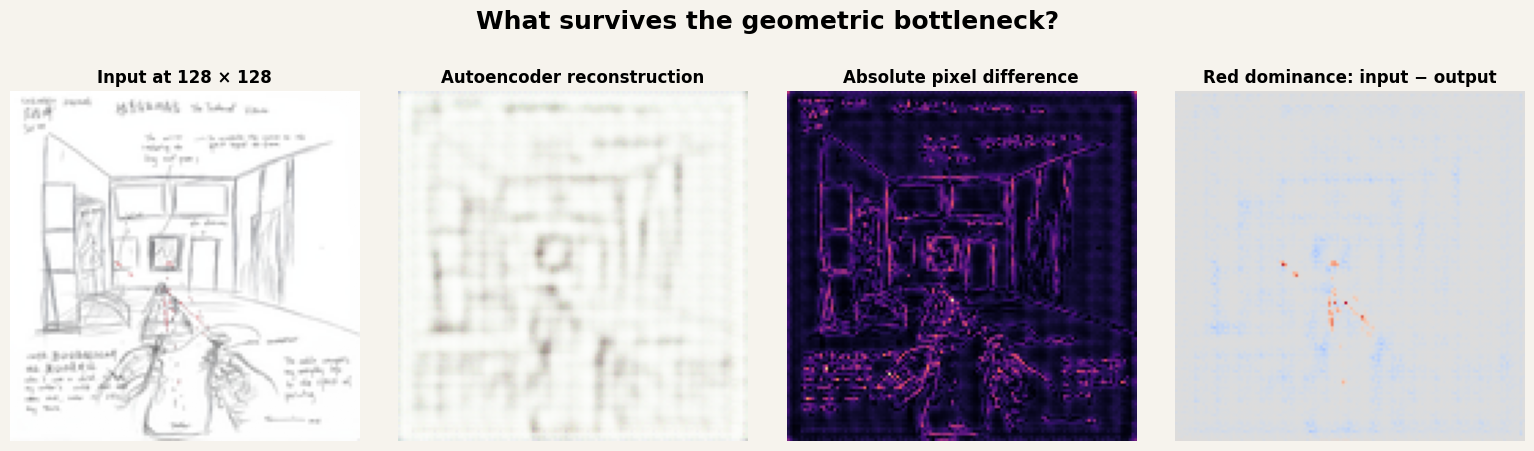

In [6]:
redInput = np.clip(
    inputArray[:, :, 0] - inputArray[:, :, 1:].mean(axis=2),
    0.0,
    1.0,
)
redOutput = np.clip(
    reconstructionArray[:, :, 0] - reconstructionArray[:, :, 1:].mean(axis=2),
    0.0,
    1.0,
)
redDifference = redInput - redOutput
redLimit = max(0.05, float(np.abs(redDifference).max()))

figure, axes = plt.subplots(1, 4, figsize=(16, 4.6), facecolor="#f6f3ed")
axes[0].imshow(inputArray)
axes[0].set_title("Input at 128 × 128", fontweight="bold")
axes[1].imshow(np.clip(reconstructionArray, 0.0, 1.0))
axes[1].set_title("Autoencoder reconstruction", fontweight="bold")
axes[2].imshow(differenceMap, cmap="magma", vmin=0.0, vmax=max(0.25, float(differenceMap.max())))
axes[2].set_title("Absolute pixel difference", fontweight="bold")
axes[3].imshow(redDifference, cmap="coolwarm", vmin=-redLimit, vmax=redLimit)
axes[3].set_title("Red dominance: input − output", fontweight="bold")

for axis in axes:
    axis.axis("off")

figure.suptitle(
    "What survives the geometric bottleneck?",
    fontsize=18,
    fontweight="bold",
)
figure.tight_layout(rect=(0.01, 0.01, 0.99, 0.92))
plt.show()

### Looking into the bottleneck

The first panel averages the 32 bottleneck channels into one map. The remaining panels show the eight channels with the highest spatial variance. Different channels preserve different local responses, but none should be treated as a named-object or meaning detector.

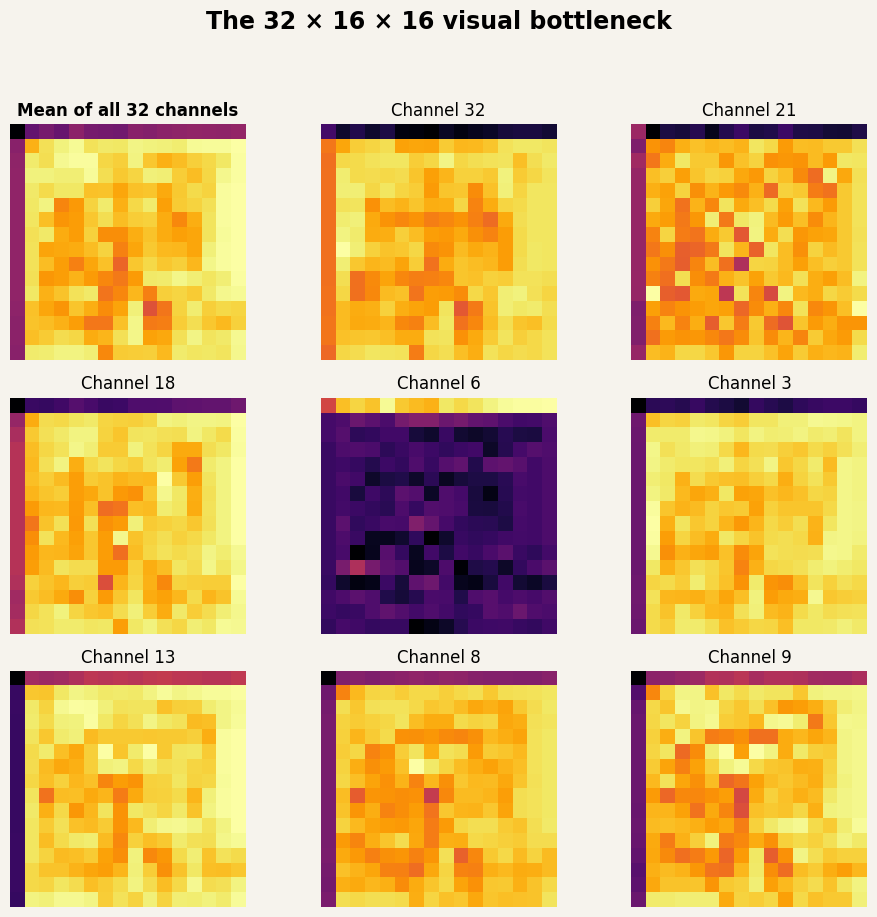

In [7]:
def normalizeMap(featureMap: np.ndarray) -> np.ndarray:
    minimumValue = float(featureMap.min())
    maximumValue = float(featureMap.max())
    if maximumValue - minimumValue < 1e-8:
        return np.zeros_like(featureMap)
    return (featureMap - minimumValue) / (maximumValue - minimumValue)


bottleneckChannels = bottleneckTensor[0].cpu()
channelVariances = bottleneckChannels.flatten(1).var(dim=1)
selectedChannels = torch.argsort(channelVariances, descending=True)[:8].tolist()

figure, axes = plt.subplots(3, 3, figsize=(10, 9.5), facecolor="#f6f3ed")
meanMap = bottleneckChannels.mean(dim=0).numpy()
axes[0, 0].imshow(normalizeMap(meanMap), cmap="inferno", vmin=0.0, vmax=1.0)
axes[0, 0].set_title("Mean of all 32 channels", fontweight="bold")
axes[0, 0].axis("off")

for plotIndex, channelIndex in enumerate(selectedChannels, start=1):
    axis = axes.flat[plotIndex]
    channelMap = bottleneckChannels[channelIndex].numpy()
    axis.imshow(normalizeMap(channelMap), cmap="inferno", vmin=0.0, vmax=1.0)
    axis.set_title(f"Channel {channelIndex + 1}")
    axis.axis("off")

figure.suptitle(
    "The 32 × 16 × 16 visual bottleneck",
    fontsize=17,
    fontweight="bold",
)
figure.tight_layout(rect=(0.02, 0.02, 0.98, 0.94))
plt.show()

### Evidence that the checkpoint was trained

The loss curves stored in the checkpoint fall over 18 epochs. This shows that the model became better at reconstructing held-out synthetic patterns; it does not show that the model understands the artwork.

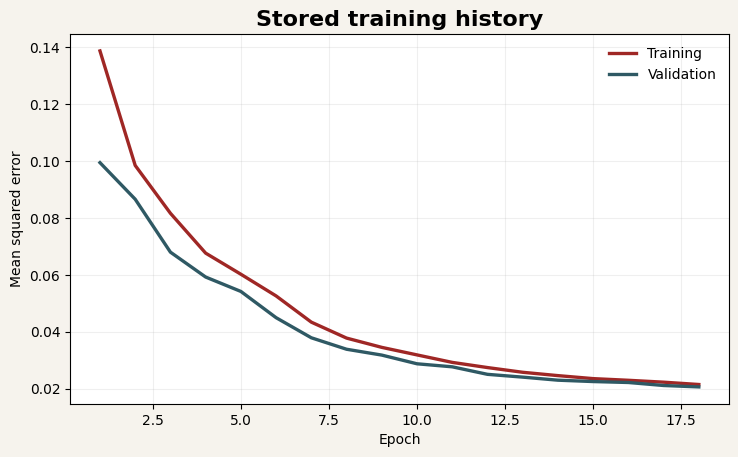

First training loss:  0.138695
Final training loss:  0.021439
Final validation loss: 0.020588


In [8]:
trainingHistory = checkpoint["history"]
epochs = np.arange(1, len(trainingHistory["train"]) + 1)

figure, axis = plt.subplots(figsize=(8.5, 4.8), facecolor="#f6f3ed")
axis.plot(epochs, trainingHistory["train"], label="Training", color="#9f2725", linewidth=2.4)
axis.plot(epochs, trainingHistory["validation"], label="Validation", color="#2f5964", linewidth=2.4)
axis.set_xlabel("Epoch")
axis.set_ylabel("Mean squared error")
axis.set_title("Stored training history", fontsize=16, fontweight="bold")
axis.grid(alpha=0.2)
axis.legend(frameon=False)
plt.show()

print(f"First training loss:  {trainingHistory['train'][0]:.6f}")
print(f"Final training loss:  {trainingHistory['train'][-1]:.6f}")
print(f"Final validation loss: {trainingHistory['validation'][-1]:.6f}")

## Checks

These assertions verify the encoder and decoder dimensions, finite values, and metric calculations.

In [9]:
assert tuple(inputTensor.shape) == (1, 3, 128, 128)
assert tuple(bottleneckTensor.shape) == (1, 32, 16, 16)
assert tuple(reconstructionTensor.shape) == tuple(inputTensor.shape)
assert torch.isfinite(bottleneckTensor).all()
assert torch.isfinite(reconstructionTensor).all()
assert 0.0 <= reconstructionTensor.min().item() <= reconstructionTensor.max().item() <= 1.0
assert math.isclose(meanSquaredError, 0.003884, rel_tol=0.02, abs_tol=1e-5)

print("PASS: encoder output is the expected 1 × 32 × 16 × 16 bottleneck.")
print("PASS: decoder reconstruction matches the input shape and contains only finite values.")
print("PASS: reconstruction values remain in the Sigmoid range [0, 1].")
print("PASS: measured MSE agrees with the recorded project result.")

PASS: encoder output is the expected 1 × 32 × 16 × 16 bottleneck.
PASS: decoder reconstruction matches the input shape and contains only finite values.
PASS: reconstruction values remain in the Sigmoid range [0, 1].
PASS: measured MSE agrees with the recorded project result.


## Takeaways

1. The autoencoder performs an actual encode–decode process: the image becomes a smaller multichannel representation and is then reconstructed.
2. The reconstruction retains repeated geometric structures more successfully than handwriting and irregular local detail.
3. The red tether is not preserved as a meaningful autobiographical symbol. Parts weaken, while a faint learned red tendency spreads elsewhere.
4. The experiment separates **formal survival** from **human interpretation**: the network compresses recurring visual patterns, not the personal significance attached to them.